In [ ]:
#@title Mount your Google Drive

import os
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
#@title Set up mount symlink

DRIVE_PATH = '/content/gdrive/My\ Drive/cs182hw4_sp25'
DRIVE_PYTHON_PATH = DRIVE_PATH.replace('\\', '')
if not os.path.exists(DRIVE_PYTHON_PATH):
  %mkdir $DRIVE_PATH

## the space in `My Drive` causes some issues,
## make a symlink to avoid this
SYM_PATH = '/content/cs182hw4'
if not os.path.exists(SYM_PATH):
  !ln -s $DRIVE_PATH $SYM_PATH

In [ ]:
!pip install numpy imageio matplotlib

%cd $SYM_PATH
if not os.path.exists("cs182sp25_public"):
  !git clone https://github.com/Berkeley-CS182/cs182sp25_public.git
%cd cs182sp25_public/hw04/q_coding_bn_drop_cnn/code

/content/gdrive/My Drive/cs182hw4_sp25
/content/gdrive/My Drive/cs182hw4_sp25/cs182sp25_public/hw04/q_coding_bn_drop_cnn/code


In [ ]:
%cd deeplearning/datasets/
!bash ./get_datasets.sh
%cd ../..

import matplotlib
%matplotlib inline
%load_ext autoreload
%autoreload 2

/content/gdrive/My Drive/cs182hw4_sp25/cs182sp25_public/hw04/q_coding_bn_drop_cnn/code/deeplearning/datasets
--2025-07-24 04:40:01--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  24.2MB/s    in 8.5s    

2025-07-24 04:40:10 (19.2 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1
/content/gdrive/MyDrive/cs182hw4_sp25/cs182sp25_public/hw04/q_coding_bn_drop_cn

In [ ]:
import numpy as np


def affine_forward(x, w, b):
    """
    Computes the forward pass for an affine (fully-connected) layer.

    The input x has shape (N, d_1, ..., d_k) and contains a minibatch of N
    examples, where each example x[i] has shape (d_1, ..., d_k). We will
    reshape each input into a vector of dimension D = d_1 * ... * d_k, and
    then transform it to an output vector of dimension M.

    Inputs:
    - x: A numpy array containing input data, of shape (N, d_1, ..., d_k)
    - w: A numpy array of weights, of shape (D, M)
    - b: A numpy array of biases, of shape (M,)

    Returns a tuple of:
    - out: output, of shape (N, M)
    - cache: (x, w, b)
    """
    out = None
    #############################################################################
    # HW1: Implement the affine forward pass. Store the result in out. You     #
    # will need to reshape the input into rows.                                 #
    #############################################################################
    out = x.reshape(x.shape[0], -1).dot(w) + b
    #############################################################################
    #                             END OF YOUR CODE                              #
    #############################################################################
    cache = (x, w, b)
    return out, cache


def affine_backward(dout, cache):
    """
    Computes the backward pass for an affine layer.

    Inputs:
    - dout: Upstream derivative, of shape (N, M)
    - cache: Tuple of:
      - x: Input data, of shape (N, d_1, ... d_k)
      - w: Weights, of shape (D, M)

    Returns a tuple of:
    - dx: Gradient with respect to x, of shape (N, d1, ..., d_k)
    - dw: Gradient with respect to w, of shape (D, M)
    - db: Gradient with respect to b, of shape (M,)
    """
    x, w, b = cache
    dx, dw, db = None, None, None
    #############################################################################
    # HW1: Implement the affine backward pass.                                 #
    #############################################################################
    dx = dout.dot(w.T).reshape(x.shape)
    dw = x.reshape(x.shape[0], -1).T.dot(dout)
    db = np.sum(dout, axis=0)
    #############################################################################
    #                             END OF YOUR CODE                              #
    #############################################################################
    return dx, dw, db


def relu_forward(x):
    """
    Computes the forward pass for a layer of rectified linear units (ReLUs).

    Input:
    - x: Inputs, of any shape

    Returns a tuple of:
    - out: Output, of the same shape as x
    - cache: x
    """
    out = None
    #############################################################################
    # HW1: Implement the ReLU forward pass.                                    #
    #############################################################################
    out = np.maximum(0, x)
    #############################################################################
    #                             END OF YOUR CODE                              #
    #############################################################################
    cache = x
    return out, cache


def relu_backward(dout, cache):
    """
    Computes the backward pass for a layer of rectified linear units (ReLUs).

    Input:
    - dout: Upstream derivatives, of any shape
    - cache: Input x, of same shape as dout

    Returns:
    - dx: Gradient with respect to x
    """
    dx, x = None, cache
    #############################################################################
    # HW1: Implement the ReLU backward pass.                                   #
    #############################################################################
    dx = (x > 0) * dout
    #############################################################################
    #                             END OF YOUR CODE                              #
    #############################################################################
    return dx
def batchnorm_forward(x, gamma, beta, bn_param):
    mode = bn_param["mode"]
    eps = bn_param.get("eps", 1e-5)
    momentum = bn_param.get("momentum", 0.9)

    N, D = x.shape
    running_mean = bn_param.get("running_mean", np.zeros(D, dtype=x.dtype))
    running_var = bn_param.get("running_var", np.zeros(D, dtype=x.dtype))

    out, cache = None, None

    if mode == "train":
        sample_mean = np.mean(x, axis=0)
        sample_var = np.var(x, axis=0)

        x_hat = (x - sample_mean) / np.sqrt(sample_var + eps)
        out = gamma * x_hat + beta

        cache = (x, x_hat, sample_mean, sample_var, gamma, beta, eps)

        running_mean = momentum * running_mean + (1 - momentum) * sample_mean
        running_var = momentum * running_var + (1 - momentum) * sample_var

    elif mode == "test":
        x_hat = (x - running_mean) / np.sqrt(running_var + eps)
        out = gamma * x_hat + beta

    else:
        raise ValueError('Invalid forward batchnorm mode "%s"' % mode)

    bn_param["running_mean"] = running_mean
    bn_param["running_var"] = running_var

    return out, cache

def batchnorm_backward(dout, cache):
    dx, dgamma, dbeta = None, None, None

    x, x_hat, mu, var, gamma, beta, eps = cache
    N, D = dout.shape

    dbeta = np.sum(dout, axis=0)
    dgamma = np.sum(dout * x_hat, axis=0)

    dx_hat = dout * gamma

    dvar = np.sum(dx_hat * (x - mu) * -0.5 * (var + eps)**(-1.5), axis=0)
    dmu = np.sum(dx_hat * -1 / np.sqrt(var + eps), axis=0) + dvar * np.sum(-2 * (x - mu), axis=0) / N

    dx = dx_hat / np.sqrt(var + eps) + dvar * 2 * (x - mu) / N + dmu / N

    return dx, dgamma, dbeta

def batchnorm_backward_alt(dout, cache):
    dx, dgamma, dbeta = None, None, None

    x_hat, gamma, x_mu, ivar, sqrtvar, var, eps = cache
    N, D = dout.shape

    dbeta = np.sum(dout, axis=0)
    dgamma = np.sum(dout * x_hat, axis=0)

    dxhat = dout * gamma
    dx = (1. / N) * ivar * (
        N * dxhat - np.sum(dxhat, axis=0)
        - x_hat * np.sum(dxhat * x_hat, axis=0)
    )

    return dx, dgamma, dbeta


def dropout_forward(x, dropout_param):
    p, mode = dropout_param["p"], dropout_param["mode"]
    if "seed" in dropout_param:
        np.random.seed(dropout_param["seed"])

    mask = None
    out = None

    if mode == "train":
        mask = (np.random.rand(*x.shape) >= p) / (1 - p)
        out = x * mask
    elif mode == "test":
        out = x

    cache = (dropout_param, mask)
    out = out.astype(x.dtype, copy=False)

    return out, cache

def dropout_backward(dout, cache):
    dropout_param, mask = cache
    mode = dropout_param["mode"]

    dx = None
    if mode == "train":
        dx = dout * mask
    elif mode == "test":
        dx = dout
    return dx


def conv_forward_naive(x, w, b, conv_param):
    N, C, H, W = x.shape
    F, _, HH, WW = w.shape
    stride = conv_param['stride']
    pad = conv_param['pad']

    H_out = 1 + (H + 2 * pad - HH) // stride
    W_out = 1 + (W + 2 * pad - WW) // stride

    x_padded = np.pad(x, ((0,), (0,), (pad,), (pad,)), mode='constant')
    out = np.zeros((N, F, H_out, W_out))

    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h1 = i * stride
                    h2 = h1 + HH
                    w1 = j * stride
                    w2 = w1 + WW
                    window = x_padded[n, :, h1:h2, w1:w2]
                    out[n, f, i, j] = np.sum(window * w[f]) + b[f]

    cache = (x, w, b, conv_param, x_padded)
    return out, cache

def conv_backward_naive(dout, cache):
    x, w, b, conv_param, x_padded = cache
    N, C, H, W = x.shape
    F, _, HH, WW = w.shape
    stride = conv_param['stride']
    pad = conv_param['pad']
    H_out = dout.shape[2]
    W_out = dout.shape[3]

    dx_padded = np.zeros_like(x_padded)
    dw = np.zeros_like(w)
    db = np.zeros_like(b)

    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h1 = i * stride
                    h2 = h1 + HH
                    w1 = j * stride
                    w2 = w1 + WW
                    dx_padded[n, :, h1:h2, w1:w2] += w[f] * dout[n, f, i, j]
                    dw[f] += x_padded[n, :, h1:h2, w1:w2] * dout[n, f, i, j]
                    db[f] += dout[n, f, i, j]

    dx = dx_padded[:, :, pad:pad+H, pad:pad+W]
    return dx, dw, db


def max_pool_forward_naive(x, pool_param):
    N, C, H, W = x.shape
    pool_height = pool_param['pool_height']
    pool_width = pool_param['pool_width']
    stride = pool_param['stride']

    H_out = 1 + (H - pool_height) // stride
    W_out = 1 + (W - pool_width) // stride

    out = np.zeros((N, C, H_out, W_out))

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h1 = i * stride
                    h2 = h1 + pool_height
                    w1 = j * stride
                    w2 = w1 + pool_width
                    window = x[n, c, h1:h2, w1:w2]
                    out[n, c, i, j] = np.max(window)

    cache = (x, pool_param)
    return out, cache


def max_pool_backward_naive(dout, cache):
    x, pool_param = cache
    N, C, H, W = x.shape
    pool_height = pool_param['pool_height']
    pool_width = pool_param['pool_width']
    stride = pool_param['stride']
    H_out = 1 + (H - pool_height) // stride
    W_out = 1 + (W - pool_width) // stride
    dx = np.zeros_like(x)

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h1 = i * stride
                    h2 = h1 + pool_height
                    w1 = j * stride
                    w2 = w1 + pool_width
                    window = x[n, c, h1:h2, w1:w2]
                    max_val = np.max(window)
                    dx_window = (window == max_val) * dout[n, c, i, j]
                    dx[n, c, h1:h2, w1:w2] += dx_window

    return dx

def spatial_batchnorm_forward(x, gamma, beta, bn_param):
    """
    Computes the forward pass for spatial batch normalization.

    Inputs:
    - x: Input data of shape (N, C, H, W)
    - gamma: Scale parameter, of shape (C,)
    - beta: Shift parameter, of shape (C,)
    - bn_param: Dictionary with batchnorm parameters

    Returns a tuple of:
    - out: Output data, of shape (N, C, H, W)
    - cache: Values needed for the backward pass
    """
    N, C, H, W = x.shape
    x_reshaped = x.transpose(0, 2, 3, 1).reshape(-1, C)
    out_reshaped, cache = batchnorm_forward(x_reshaped, gamma, beta, bn_param)
    out = out_reshaped.reshape(N, H, W, C).transpose(0, 3, 1, 2)

    return out, cache


def spatial_batchnorm_backward(dout, cache):
    """
    Computes the backward pass for spatial batch normalization.

    Inputs:
    - dout: Upstream derivatives, of shape (N, C, H, W)
    - cache: Values from the forward pass

    Returns a tuple of:
    - dx: Gradient with respect to inputs, of shape (N, C, H, W)
    - dgamma: Gradient with respect to scale parameter, of shape (C,)
    - dbeta: Gradient with respect to shift parameter, of shape (C,)
    """
    N, C, H, W = dout.shape
    dout_reshaped = dout.transpose(0, 2, 3, 1).reshape(-1, C)
    dx, dgamma, dbeta = batchnorm_backward(dout_reshaped, cache)
    dx = dx.reshape(N, H, W, C).transpose(0, 3, 1, 2)

    return dx, dgamma, dbeta

def svm_loss(x, y):
    """
    Computes the loss and gradient using for multiclass SVM classification.

    Inputs:
    - x: Input data, of shape (N, C) where x[i, j] is the score for the jth class
      for the ith input.
    - y: Vector of labels, of shape (N,) where y[i] is the label for x[i] and
      0 <= y[i] < C

    Returns a tuple of:
    - loss: Scalar giving the loss
    - dx: Gradient of the loss with respect to x
    """
    N = x.shape[0]
    correct_class_scores = x[np.arange(N), y]
    margins = np.maximum(0, x - correct_class_scores[:, np.newaxis] + 1.0)
    margins[np.arange(N), y] = 0
    loss = np.sum(margins) / N
    num_pos = np.sum(margins > 0, axis=1)
    dx = np.zeros_like(x)
    dx[margins > 0] = 1
    dx[np.arange(N), y] -= num_pos
    dx /= N
    return loss, dx


def softmax_loss(x, y):
    """
    Computes the loss and gradient for softmax classification.

    Inputs:
    - x: Input data, of shape (N, C) where x[i, j] is the score for the jth class
      for the ith input.
    - y: Vector of labels, of shape (N,) where y[i] is the label for x[i] and
      0 <= y[i] < C

    Returns a tuple of:
    - loss: Scalar giving the loss
    - dx: Gradient of the loss with respect to x
    """
    probs = np.exp(x - np.max(x, axis=1, keepdims=True))
    probs /= np.sum(probs, axis=1, keepdims=True)
    N = x.shape[0]
    loss = -np.sum(np.log(probs[np.arange(N), y])) / N
    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx


In [ ]:
# As usual, a bit of setup

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from deeplearning.data_utils import get_CIFAR10_data
from deeplearning.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from deeplearning.solver import Solver
import random
import torch
seed = 7
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

os.makedirs("submission_logs", exist_ok=True)

def abs_error(x, y):
    return np.max(np.abs(x - y))

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [ ]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in data.items():
    print ('%s: ' % k, v.shape)

deeplearning/datasets/cifar-10-batches-py/data_batch_1
deeplearning/datasets/cifar-10-batches-py/data_batch_2
deeplearning/datasets/cifar-10-batches-py/data_batch_3
deeplearning/datasets/cifar-10-batches-py/data_batch_4
deeplearning/datasets/cifar-10-batches-py/data_batch_5
deeplearning/datasets/cifar-10-batches-py/test_batch
X_train:  (49000, 3, 32, 32)
y_train:  (49000,)
X_val:  (1000, 3, 32, 32)
y_val:  (1000,)
X_test:  (1000, 3, 32, 32)
y_test:  (1000,)


In [ ]:
# Check the training-time forward pass by checking means and variances
# of features both before and after batch normalization

# Simulate the forward pass for a two-layer network
N, D1, D2, D3 = 200, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print ('Before batch normalization:')
print ('  means: ', a.mean(axis=0))
print ('  stds: ', a.std(axis=0))

# Means should be close to zero and stds close to one
print ('After batch normalization (gamma=1, beta=0)')
a_norm, _ = batchnorm_forward(a, np.ones(D3), np.zeros(D3), {'mode': 'train'})
print ('  mean: ', a_norm.mean(axis=0))  # expected: (approx.) [0, 0, 0]
print ('  std: ', a_norm.std(axis=0))  # expected: (approx.) [1, 1, 1]

# Now means should be close to beta and stds close to gamma
gamma = np.asarray([1.0, 2.0, 3.0])
beta = np.asarray([11.0, 12.0, 13.0])
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print ('After batch normalization (nontrivial gamma, beta)')
print ('  means: ', a_norm.mean(axis=0))  # expected: (approx.) [11, 12, 13]
print ('  stds: ', a_norm.std(axis=0))  # expected: (approx.) [1, 2, 3]

Before batch normalization:
  means:  [-33.90168215  18.46269328  -7.49068667]
  stds:  [38.72112268 29.39668975 31.14272252]
After batch normalization (gamma=1, beta=0)
  mean:  [ 4.80726570e-16  2.98649994e-16 -2.77555756e-17]
  std:  [1.         0.99999999 0.99999999]
After batch normalization (nontrivial gamma, beta)
  means:  [11. 12. 13.]
  stds:  [1.         1.99999999 2.99999998]


In [ ]:
# Check the test-time forward pass by running the training-time
# forward pass many times to warm up the running averages, and then
# checking the means and variances of activations after a test-time
# forward pass.
N, D1, D2, D3 = 200, 50, 60, 3
np.random.seed(seed)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)

bn_param = {'mode': 'train'}
gamma = np.ones(D3)
beta = np.zeros(D3)
for t in range(50):
    X = np.random.randn(N, D1)
    a = np.maximum(0, X.dot(W1)).dot(W2)
    batchnorm_forward(a, gamma, beta, bn_param)
bn_param['mode'] = 'test'
X = np.random.randn(N, D1)
a = np.maximum(0, X.dot(W1)).dot(W2)
a_norm, _ = batchnorm_forward(a, gamma, beta, bn_param)

# Means should be close to zero and stds close to one, but will be
# noisier than training-time forward passes.
print ('After batch normalization (test-time):')
print ('  means: ', a_norm.mean(axis=0))
print ('  stds: ', a_norm.std(axis=0))
expected_a_norm = np.array(
    [[-7.37859885e-01,  2.10050591e+00, -3.24286480e-01],
    [ 2.02781031e+00,  1.92492178e-01,  1.54852388e+00],
    [ 5.44242949e-01,  1.07389911e+00,  8.06464618e-01],
    [-2.25599789e-02,  7.64501325e-01, -3.03045313e-01],
    [-9.74592587e-01,  6.01731799e-01, -6.57200019e-03]])
print ('Abs error of a_norm: ', abs_error(a_norm[:5, :], expected_a_norm))

After batch normalization (test-time):
  means:  [-0.00967681  0.01315673  0.00748036]
  stds:  [1.07009997 1.01651564 0.88995918]
Abs error of a_norm:  4.342406878521388e-09


In [ ]:
N, D = 100, 500
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
out, cache = batchnorm_forward(x, gamma, beta, bn_param)

t1 = time.time()
# repeat backwards passes multiple times for stability
for r in range(1000):
    dx1, dgamma1, dbeta1 = batchnorm_backward(dout, cache)
t2 = time.time()
for r in range(1000):
    dx2, dgamma2, dbeta2 = batchnorm_backward_alt(dout, cache)
t3 = time.time()

print ('dx difference: ', rel_error(dx1, dx2))
print ('dgamma difference: ', rel_error(dgamma1, dgamma2))
print ('dbeta difference: ', rel_error(dbeta1, dbeta2))
print ('speedup: %.2fx' % ((t2 - t1) / (t3 - t2)))

dx difference:  1.0
dgamma difference:  1.0
dbeta difference:  0.0
speedup: 2.05x


In [ ]:
import numpy as np

class FullyConnectedNet(object):
    def __init__(
        self,
        hidden_dims,
        input_dim=3 * 32 * 32,
        num_classes=10,
        dropout=0,
        use_batchnorm=False,
        reg=0.0,
        weight_scale=1e-2,
        dtype=np.float32,
        seed=None,
    ):
        self.use_batchnorm = use_batchnorm
        self.use_dropout = dropout > 0
        self.reg = reg
        self.num_layers = 1 + len(hidden_dims)
        self.dtype = dtype
        self.params = {}

        # Initialize weights/biases (and batchnorm params)
        dims = [input_dim] + hidden_dims + [num_classes]
        for i in range(self.num_layers):
            self.params[f"W{i+1}"] = np.random.randn(dims[i], dims[i+1]) * weight_scale
            self.params[f"b{i+1}"] = np.zeros(dims[i+1])
            if self.use_batchnorm and i < self.num_layers - 1:
                self.params[f"gamma{i+1}"] = np.ones(dims[i+1])
                self.params[f"beta{i+1}"] = np.zeros(dims[i+1])

        # Setup dropout and batchnorm parameters
        self.dropout_param = {}
        if self.use_dropout:
            self.dropout_param = {"mode": "train", "p": dropout}
            if seed is not None:
                self.dropout_param["seed"] = seed

        self.bn_params = []
        if self.use_batchnorm:
            self.bn_params = [{"mode": "train"} for _ in range(self.num_layers - 1)]

        # Ensure correct dtype
        for k, v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        X = X.astype(self.dtype)
        mode = "test" if y is None else "train"

        # Set modes for dropout/batchnorm
        if self.use_dropout:
            self.dropout_param["mode"] = mode
        if self.use_batchnorm:
            for bn in self.bn_params:
                bn["mode"] = mode

        # FORWARD PASS
        caches, dropout_caches = [], []
        out = X

        for i in range(1, self.num_layers):
            W, b = self.params[f"W{i}"], self.params[f"b{i}"]
            out, fc_cache = affine_forward(out, W, b)

            if self.use_batchnorm:
                gamma = self.params[f"gamma{i}"]
                beta = self.params[f"beta{i}"]
                bn_param = self.bn_params[i - 1]
                out, bn_cache = batchnorm_forward(out, gamma, beta, bn_param)
                fc_cache = (fc_cache, bn_cache)

            out, relu_cache = relu_forward(out)

            if self.use_dropout:
                out, do_cache = dropout_forward(out, self.dropout_param)
            else:
                do_cache = None
            dropout_caches.append(do_cache)

            caches.append((fc_cache, relu_cache))

        # Final affine layer (no batchnorm/relu/dropout)
        Wf, bf = self.params[f"W{self.num_layers}"], self.params[f"b{self.num_layers}"]
        scores, final_cache = affine_forward(out, Wf, bf)

        # If test mode, return early
        if mode == "test":
            return scores

        # BACKWARD PASS
        loss, grads = 0.0, {}
        loss, ds = softmax_loss(scores, y)

        # Add L2 regularization
        for i in range(1, self.num_layers + 1):
            Wi = self.params[f"W{i}"]
            loss += 0.5 * self.reg * np.sum(Wi * Wi)

        # Final layer gradient
        dout, dWf, dbf = affine_backward(ds, final_cache)
        grads[f"W{self.num_layers}"] = dWf + self.reg * Wf
        grads[f"b{self.num_layers}"] = dbf

        # Backpropagate through hidden layers
        for i in reversed(range(1, self.num_layers)):
            fc_cache, relu_cache = caches[i - 1]

            # Dropout backwards
            if self.use_dropout:
                do_cache = dropout_caches[i - 1]
                if do_cache is not None:
                    dout = dropout_backward(dout, do_cache)

            dout = relu_backward(dout, relu_cache)

            if self.use_batchnorm:
                fc_cache, bn_cache = fc_cache
                dout, dgamma, dbeta = batchnorm_backward(dout, bn_cache)
                grads[f"gamma{i}"] = dgamma
                grads[f"beta{i}"] = dbeta

            dout, dWi, dbi = affine_backward(dout, fc_cache)
            Wi = self.params[f"W{i}"]
            grads[f"W{i}"] = dWi + self.reg * Wi
            grads[f"b{i}"] = dbi

        return loss, grads


In [ ]:
N, D, H1, H2, C = 2, 15, 20, 30, 10

model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=0, weight_scale=5e-2, dtype=np.float64,
                            use_batchnorm=True)
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H1).reshape(D, H1)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H1)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H1*H2).reshape(H1, H2)
model.params['b2'] = np.linspace(-0.9, 0.1, num=H2)
model.params['W3'] = np.linspace(-0.3, 0.4, num=H2*C).reshape(H2, C)
model.params['b3'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T

expected_bn_forward_output = np.array([[0.28397701, 0.46532063, 0.64666426, 0.82800788, 1.0093515, 1.19069513,
                                            1.37203875, 1.55338238,  1.734726, 1.91606962],
                                       [-0.9, -0.78888889, -0.67777778, -0.56666667, -0.45555556, -0.34444444,
                                            -0.23333333, -0.12222222, -0.01111111, 0.1]])

# Checks if initial forward pass is correct with batchnorm
init_scores = model.loss(X)
print('initial predictions error: %.2e' % rel_error(init_scores, expected_bn_forward_output))

X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print ('Running check with reg = ', reg)
    model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=reg, weight_scale=5e-2, dtype=np.float64,
                            use_batchnorm=True)


    loss, grads = model.loss(X, y)
    print ('Initial loss: ', loss)

    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print ('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
    if reg == 0: print

initial predictions error: 1.00e+00
Running check with reg =  0
Initial loss:  2.1676463586387182
W1 relative error: 7.11e-04
W2 relative error: 1.60e-06
W3 relative error: 4.67e-10
b1 relative error: 1.39e-09
b2 relative error: 1.11e-08
b3 relative error: 2.37e-10
beta1 relative error: 4.73e-08
beta2 relative error: 1.20e-09
gamma1 relative error: 1.23e-08
gamma2 relative error: 7.22e-09
Running check with reg =  3.14
Initial loss:  7.194409521565678
W1 relative error: 1.55e-05
W2 relative error: 3.40e-06
W3 relative error: 1.48e-08
b1 relative error: 4.44e-08
b2 relative error: 2.22e-08
b3 relative error: 2.81e-10
beta1 relative error: 2.99e-09
beta2 relative error: 1.58e-08
gamma1 relative error: 1.79e-09
gamma2 relative error: 2.85e-08


In [ ]:
x_shape = (2, 3, 4, 4)
w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

conv_param = {'stride': 2, 'pad': 1}
out, _ = conv_forward_naive(x, w, b, conv_param)
correct_out = np.array([[[[[-0.08759809, -0.10987781],
                           [-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],
                           [ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],
                           [ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],
                           [-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],
                           [ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],
                           [ 2.38090835,  2.38247847]]]]])

# Compare your output to ours; difference should be around 1e-8
print ('Testing conv_forward_naive')
print ('difference: ', rel_error(out, correct_out))

Testing conv_forward_naive
difference:  2.2121476417505994e-08


In [ ]:
import numpy as np

from deeplearning import optim


class Solver(object):
    """
    A Solver encapsulates all the logic necessary for training classification
    models. The Solver performs stochastic gradient descent using different
    update rules defined in optim.py.

    The solver accepts both training and validataion data and labels so it can
    periodically check classification accuracy on both training and validation
    data to watch out for overfitting.

    To train a model, you will first construct a Solver instance, passing the
    model, dataset, and various optoins (learning rate, batch size, etc) to the
    constructor. You will then call the train() method to run the optimization
    procedure and train the model.

    After the train() method returns, model.params will contain the parameters
    that performed best on the validation set over the course of training.
    In addition, the instance variable solver.loss_history will contain a list
    of all losses encountered during training and the instance variables
    solver.train_acc_history and solver.val_acc_history will be lists containing
    the accuracies of the model on the training and validation set at each epoch.

    Example usage might look something like this:

    data = {
      'X_train': # training data
      'y_train': # training labels
      'X_val': # validation data
      'X_train': # validation labels
    }
    model = MyAwesomeModel(hidden_size=100, reg=10)
    solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': 1e-3,
                    },
                    lr_decay=0.95,
                    num_epochs=10, batch_size=100,
                    print_every=100)
    solver.train()


    A Solver works on a model object that must conform to the following API:

    - model.params must be a dictionary mapping string parameter names to numpy
      arrays containing parameter values.

    - model.loss(X, y) must be a function that computes training-time loss and
      gradients, and test-time classification scores, with the following inputs
      and outputs:

      Inputs:
      - X: Array giving a minibatch of input data of shape (N, d_1, ..., d_k)
      - y: Array of labels, of shape (N,) giving labels for X where y[i] is the
        label for X[i].

      Returns:
      If y is None, run a test-time forward pass and return:
      - scores: Array of shape (N, C) giving classification scores for X where
        scores[i, c] gives the score of class c for X[i].

      If y is not None, run a training time forward and backward pass and return
      a tuple of:
      - loss: Scalar giving the loss
      - grads: Dictionary with the same keys as self.params mapping parameter
        names to gradients of the loss with respect to those parameters.
    """

    def __init__(self, model, data, **kwargs):
        """
        Construct a new Solver instance.

        Required arguments:
        - model: A model object conforming to the API described above
        - data: A dictionary of training and validation data with the following:
          'X_train': Array of shape (N_train, d_1, ..., d_k) giving training images
          'X_val': Array of shape (N_val, d_1, ..., d_k) giving validation images
          'y_train': Array of shape (N_train,) giving labels for training images
          'y_val': Array of shape (N_val,) giving labels for validation images

        Optional arguments:
        - update_rule: A string giving the name of an update rule in optim.py.
          Default is 'sgd'.
        - optim_config: A dictionary containing hyperparameters that will be
          passed to the chosen update rule. Each update rule requires different
          hyperparameters (see optim.py) but all update rules require a
          'learning_rate' parameter so that should always be present.
        - lr_decay: A scalar for learning rate decay; after each epoch the learning
          rate is multiplied by this value.
        - batch_size: Size of minibatches used to compute loss and gradient during
          training.
        - num_epochs: The number of epochs to run for during training.
        - print_every: Integer; training losses will be printed every print_every
          iterations.
        - verbose: Boolean; if set to false then no output will be printed during
          training.
        """
        self.model = model
        self.X_train = data['X_train']
        self.y_train = data['y_train']
        self.X_val = data['X_val']
        self.y_val = data['y_val']

        # Unpack keyword arguments
        self.update_rule = kwargs.pop('update_rule', 'sgd')
        self.optim_config = kwargs.pop('optim_config', {})
        self.lr_decay = kwargs.pop('lr_decay', 1.0)
        self.batch_size = kwargs.pop('batch_size', 100)
        self.num_epochs = kwargs.pop('num_epochs', 10)

        self.print_every = kwargs.pop('print_every', 10)
        self.verbose = kwargs.pop('verbose', True)

        # Throw an error if there are extra keyword arguments
        if len(kwargs) > 0:
            extra = ', '.join('"%s"' % k for k in kwargs.keys())
            raise ValueError('Unrecognized arguments %s' % extra)

        # Make sure the update rule exists, then replace the string
        # name with the actual function
        if not hasattr(optim, self.update_rule):
            raise ValueError('Invalid update_rule "%s"' % self.update_rule)
        self.update_rule = getattr(optim, self.update_rule)

        self._reset()

    def _reset(self):
        """
        Set up some book-keeping variables for optimization. Don't call this
        manually.
        """
        # Set up some variables for book-keeping
        self.epoch = 0
        self.best_val_acc = 0
        self.best_params = {}
        self.loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []

        # Make a deep copy of the optim_config for each parameter
        self.optim_configs = {}
        for p in self.model.params:
            d = {k: v for k, v in self.optim_config.items()}
            self.optim_configs[p] = d

    def _step(self):
        """
        Make a single gradient update. This is called by train() and should not
        be called manually.
        """
        # Make a minibatch of training data
        num_train = self.X_train.shape[0]
        batch_mask = np.random.choice(num_train, self.batch_size)
        X_batch = self.X_train[batch_mask]
        y_batch = self.y_train[batch_mask]

        # Compute loss and gradient
        loss, grads = self.model.loss(X_batch, y_batch)
        self.loss_history.append(loss)

        # Perform a parameter update
        for p, w in self.model.params.items():
            dw = grads[p]
            config = self.optim_configs[p]
            next_w, next_config = self.update_rule(w, dw, config)
            self.model.params[p] = next_w
            self.optim_configs[p] = next_config

    def record_histories_as_npz(self, filename):
        tl_hist = np.array(self.loss_history)
        ta_hist = np.array(self.train_acc_history)
        va_hist = np.array(self.val_acc_history)
        np.savez(filename, train_losses=tl_hist, train_accs=ta_hist, val_accs=va_hist)

    def check_accuracy(self, X, y, num_samples=None, batch_size=100):
        """
        Check accuracy of the model on the provided data.

        Inputs:
        - X: Array of data, of shape (N, d_1, ..., d_k)
        - y: Array of labels, of shape (N,)
        - num_samples: If not None, subsample the data and only test the model
          on num_samples datapoints.
        - batch_size: Split X and y into batches of this size to avoid using too
          much memory.

        Returns:
        - acc: Scalar giving the fraction of instances that were correctly
          classified by the model.
        """

        # Maybe subsample the data
        N = X.shape[0]
        if num_samples is not None and N > num_samples:
            mask = np.random.choice(N, num_samples)
            N = num_samples
            X = X[mask]
            y = y[mask]

        # Compute predictions in batches
        num_batches = N // batch_size
        if N % batch_size != 0:
            num_batches += 1
        y_pred = []
        for i in range(num_batches):
            start = i * batch_size
            end = (i + 1) * batch_size
            scores = self.model.loss(X[start:end])
            y_pred.append(np.argmax(scores, axis=1))
        y_pred = np.hstack(y_pred)
        acc = np.mean(y_pred == y)

        return acc

    def train(self):
        """
        Run optimization to train the model.
        """
        num_train = self.X_train.shape[0]
        iterations_per_epoch = max(num_train // self.batch_size, 1)
        num_iterations = self.num_epochs * iterations_per_epoch

        for t in range(num_iterations):
            self._step()

            # Maybe print training loss
            if self.verbose and t % self.print_every == 0:
                print('(Iteration %d / %d) loss: %f' % (t + 1, num_iterations, self.loss_history[-1]))

            # At the end of every epoch, increment the epoch counter and decay the
            # learning rate.
            epoch_end = (t + 1) % iterations_per_epoch == 0
            if epoch_end:
                self.epoch += 1
                for k in self.optim_configs:
                    self.optim_configs[k]['learning_rate'] *= self.lr_decay

            # Check train and val accuracy on the first iteration, the last
            # iteration, and at the end of each epoch.
            first_it = (t == 0)
            last_it = (t == num_iterations + 1)
            if first_it or last_it or epoch_end:
                train_acc = self.check_accuracy(self.X_train, self.y_train, num_samples=1000)
                val_acc = self.check_accuracy(self.X_val, self.y_val)
                self.train_acc_history.append(train_acc)
                self.val_acc_history.append(val_acc)

                if self.verbose:
                    print('(Epoch %d / %d) train acc: %f; val_acc: %f' % (
                        self.epoch, self.num_epochs, train_acc, val_acc))

                # Keep track of the best model
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_params = {}
                    for k, v in self.model.params.items():
                        self.best_params[k] = v.copy()

        # At the end of training swap the best params into the model
        self.model.params = self.best_params


In [ ]:
#debugging
#from deeplearning.layers import *
#from deeplearning.classifiers.fc_net import *

# Try training a very deep net with batchnorm
hidden_dims = [100, 100, 100, 100, 100]

num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=True)
model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=False)
np.random.seed(seed)
bn_solver = Solver(bn_model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=200)
bn_solver.train()

np.random.seed(seed)
solver = Solver(model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=200)
solver.train()

(Iteration 1 / 200) loss: 2.300373
(Epoch 0 / 10) train acc: 0.111000; val_acc: 0.103000
(Epoch 1 / 10) train acc: 0.287000; val_acc: 0.259000
(Epoch 2 / 10) train acc: 0.431000; val_acc: 0.287000
(Epoch 3 / 10) train acc: 0.509000; val_acc: 0.305000
(Epoch 4 / 10) train acc: 0.543000; val_acc: 0.344000
(Epoch 5 / 10) train acc: 0.627000; val_acc: 0.312000
(Epoch 6 / 10) train acc: 0.638000; val_acc: 0.311000
(Epoch 7 / 10) train acc: 0.715000; val_acc: 0.312000
(Epoch 8 / 10) train acc: 0.753000; val_acc: 0.302000
(Epoch 9 / 10) train acc: 0.782000; val_acc: 0.301000
(Epoch 10 / 10) train acc: 0.794000; val_acc: 0.295000
(Iteration 1 / 200) loss: 2.302480
(Epoch 0 / 10) train acc: 0.119000; val_acc: 0.122000
(Epoch 1 / 10) train acc: 0.163000; val_acc: 0.170000
(Epoch 2 / 10) train acc: 0.233000; val_acc: 0.220000
(Epoch 3 / 10) train acc: 0.300000; val_acc: 0.270000
(Epoch 4 / 10) train acc: 0.381000; val_acc: 0.306000
(Epoch 5 / 10) train acc: 0.409000; val_acc: 0.305000
(Epoch 6 / 

In [ ]:

class TwoLayerNet(object):
    """
    A two-layer fully-connected neural network with ReLU nonlinearity and
    softmax loss that uses a modular layer design. We assume an input dimension
    of D, a hidden dimension of H, and perform classification over C classes.

    The architecure should be affine - relu - affine - softmax.

    Note that this class does not implement gradient descent; instead, it
    will interact with a separate Solver object that is responsible for running
    optimization.

    The learnable parameters of the model are stored in the dictionary
    self.params that maps parameter names to numpy arrays.
    """

    def __init__(
        self,
        input_dim=3 * 32 * 32,
        hidden_dim=100,
        num_classes=10,
        weight_scale=1e-2,
        reg=0.0,
    ):
        """
        Initialize a new network.

        Inputs:
        - input_dim: An integer giving the size of the input
        - hidden_dim: An integer giving the size of the hidden layer
        - num_classes: An integer giving the number of classes to classify
        - dropout: Scalar between 0 and 1 giving dropout strength.
        - weight_scale: Scalar giving the standard deviation for random
          initialization of the weights.
        - reg: Scalar giving L2 regularization strength.
        """
        self.params = {}
        self.reg = reg

        ############################################################################
        # HW1: Initialize the weights and biases of the two-layer net. Weights    #
        # should be initialized from a Gaussian with standard deviation equal to   #
        # weight_scale, and biases should be initialized to zero. All weights and  #
        # biases should be stored in the dictionary self.params, with first layer  #
        # weights and biases using the keys 'W1' and 'b1' and second layer weights #
        # and biases using the keys 'W2' and 'b2'.                                 #
        ############################################################################
        self.params["W1"] = weight_scale * np.random.randn(input_dim, hidden_dim)
        self.params["b1"] = np.zeros(hidden_dim)
        self.params["W2"] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params["b2"] = np.zeros(num_classes)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

    def loss(self, X, y=None):
        """
        Compute loss and gradient for a minibatch of data.

        Inputs:
        - X: Array of input data of shape (N, d_1, ..., d_k)
        - y: Array of labels, of shape (N,). y[i] gives the label for X[i].

        Returns:
        If y is None, then run a test-time forward pass of the model and return:
        - scores: Array of shape (N, C) giving classification scores, where
          scores[i, c] is the classification score for X[i] and class c.

        If y is not None, then run a training-time forward and backward pass and
        return a tuple of:
        - loss: Scalar value giving the loss
        - grads: Dictionary with the same keys as self.params, mapping parameter
          names to gradients of the loss with respect to those parameters.
        """
        scores = None
        ############################################################################
        # HW1: Implement the forward pass for the two-layer net, computing the    #
        # class scores for X and storing them in the scores variable.              #
        ############################################################################
        layer1_out, cache1 = affine_relu_forward(
            X, self.params["W1"], self.params["b1"]
        )
        layer2_out, cache2 = affine_forward(
            layer1_out, self.params["W2"], self.params["b2"]
        )
        scores = layer2_out
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

        # If y is None then we are in test mode so just return scores
        if y is None:
            return scores

        loss, grads = 0, {}
        ############################################################################
        # HW1: Implement the backward pass for the two-layer net. Store the loss  #
        # in the loss variable and gradients in the grads dictionary. Compute data #
        # loss using softmax, and make sure that grads[k] holds the gradients for  #
        # self.params[k]. Don't forget to add L2 regularization on the weights,    #
        # but not the biases.                                                      #
        #                                                                          #
        # NOTE: To ensure that your implementation matches ours and you pass the   #
        # automated tests, make sure that your L2 regularization includes a factor #
        # of 0.5 to simplify the expression for the gradient.                      #
        ############################################################################
        loss, dout = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(self.params["W1"] ** 2)) + 0.5 * self.reg * (
            np.sum(self.params["W2"] ** 2)
        )
        dout, grads["W2"], grads["b2"] = affine_backward(dout, cache2)
        _, grads["W1"], grads["b1"] = affine_relu_backward(dout, cache1)
        grads["W2"] += self.reg * self.params["W2"]
        grads["W1"] += self.reg * self.params["W1"]
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

        return loss, grads



In [ ]:

# Try training a very deep net with batchnorm
hidden_dims = [100, 100, 100, 100, 100]

num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=True)
model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=False)
np.random.seed(seed)
bn_solver = Solver(bn_model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=200)
bn_solver.train()

np.random.seed(seed)
solver = Solver(model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=200)
solver.train()

(Iteration 1 / 200) loss: 2.303500
(Epoch 0 / 10) train acc: 0.128000; val_acc: 0.105000
(Epoch 1 / 10) train acc: 0.316000; val_acc: 0.250000
(Epoch 2 / 10) train acc: 0.453000; val_acc: 0.331000
(Epoch 3 / 10) train acc: 0.540000; val_acc: 0.328000
(Epoch 4 / 10) train acc: 0.574000; val_acc: 0.318000
(Epoch 5 / 10) train acc: 0.620000; val_acc: 0.321000
(Epoch 6 / 10) train acc: 0.648000; val_acc: 0.322000
(Epoch 7 / 10) train acc: 0.708000; val_acc: 0.308000
(Epoch 8 / 10) train acc: 0.747000; val_acc: 0.321000
(Epoch 9 / 10) train acc: 0.783000; val_acc: 0.321000
(Epoch 10 / 10) train acc: 0.818000; val_acc: 0.333000
(Iteration 1 / 200) loss: 2.302234
(Epoch 0 / 10) train acc: 0.146000; val_acc: 0.159000
(Epoch 1 / 10) train acc: 0.189000; val_acc: 0.179000
(Epoch 2 / 10) train acc: 0.278000; val_acc: 0.255000
(Epoch 3 / 10) train acc: 0.333000; val_acc: 0.287000
(Epoch 4 / 10) train acc: 0.408000; val_acc: 0.310000
(Epoch 5 / 10) train acc: 0.461000; val_acc: 0.305000
(Epoch 6 / 

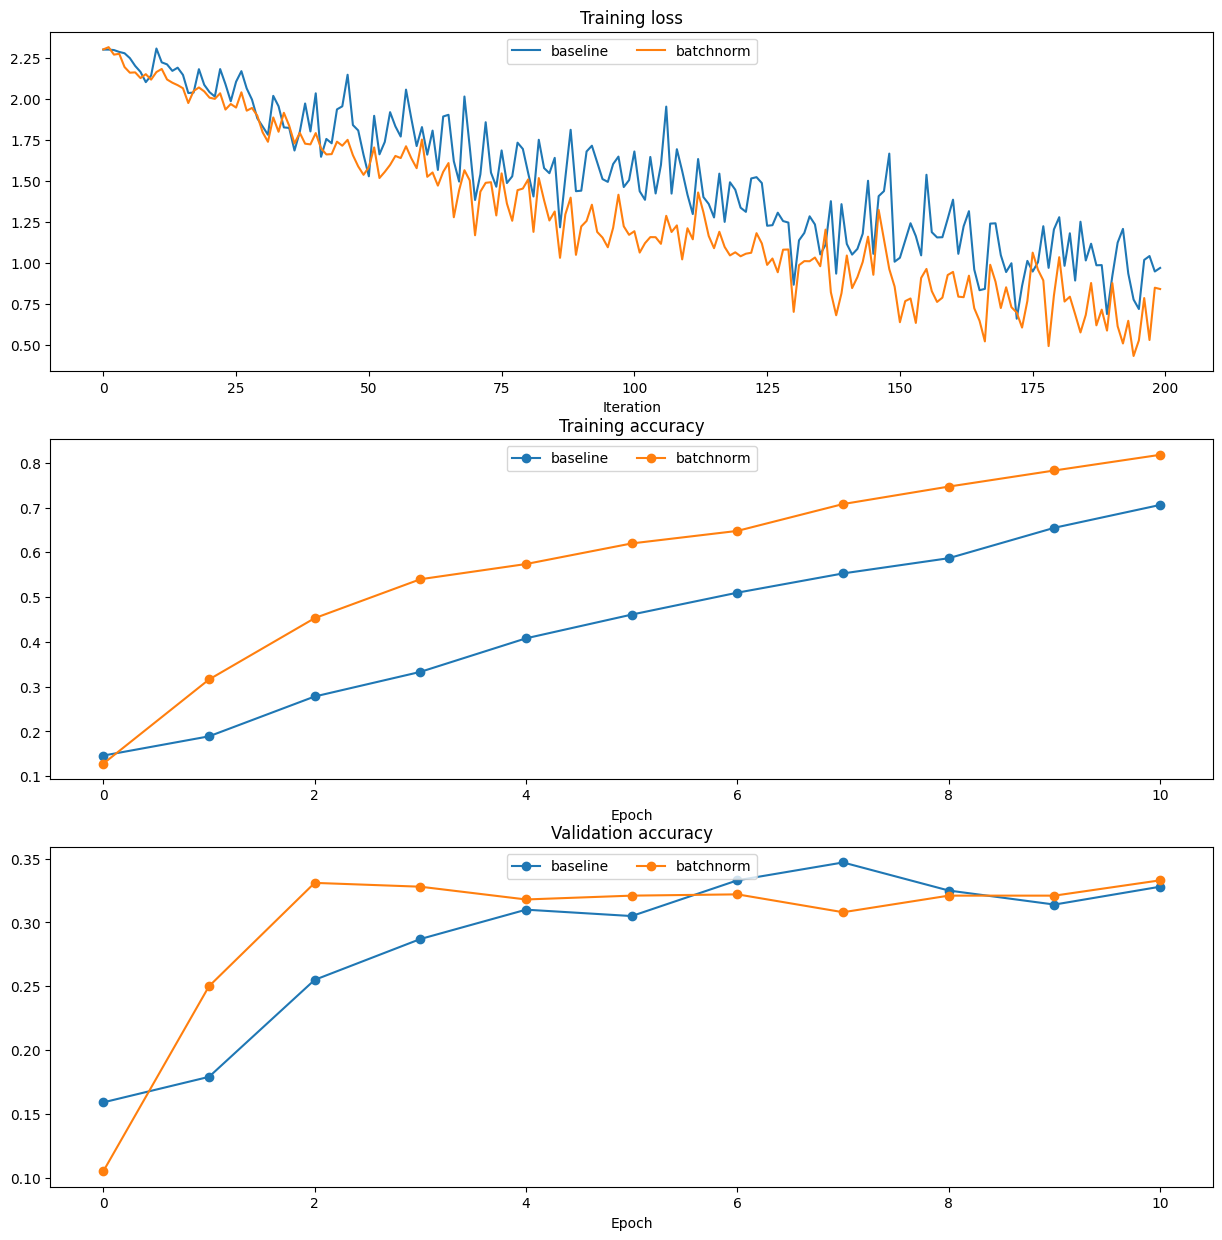

In [ ]:
plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 1)
plt.plot(solver.loss_history, '-', label='baseline')
plt.plot(bn_solver.loss_history, '-', label='batchnorm')

plt.subplot(3, 1, 2)
plt.plot(solver.train_acc_history, '-o', label='baseline')
plt.plot(bn_solver.train_acc_history, '-o', label='batchnorm')

plt.subplot(3, 1, 3)
plt.plot(solver.val_acc_history, '-o', label='baseline')
plt.plot(bn_solver.val_acc_history, '-o', label='batchnorm')

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()

solver.record_histories_as_npz('submission_logs/compare_bn_deep_networks_no_bn.npz')
bn_solver.record_histories_as_npz('submission_logs/compare_bn_deep_networks_with_bn.npz')

In [ ]:
# Try training a very deep net with batchnorm
hidden_dims = [50, 50, 50, 50, 50, 50, 50]

num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

bn_solvers = {}
solvers = {}
weight_scales = np.logspace(-4, 0, num=20)
for i, weight_scale in enumerate(weight_scales):
    print ('Running weight scale %d / %d' % (i + 1, len(weight_scales)))
    bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=True)
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, use_batchnorm=False)

    np.random.seed(seed)
    bn_solver = Solver(bn_model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    bn_solver.train()
    bn_solvers[weight_scale] = bn_solver

    np.random.seed(seed)
    solver = Solver(model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    solver.train()
    solvers[weight_scale] = solver

Running weight scale 1 / 20
Running weight scale 2 / 20
Running weight scale 3 / 20
Running weight scale 4 / 20
Running weight scale 5 / 20
Running weight scale 6 / 20
Running weight scale 7 / 20
Running weight scale 8 / 20
Running weight scale 9 / 20
Running weight scale 10 / 20
Running weight scale 11 / 20
Running weight scale 12 / 20
Running weight scale 13 / 20
Running weight scale 14 / 20
Running weight scale 15 / 20
Running weight scale 16 / 20


/tmp/ipython-input-9-4011303982.py:401: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(probs[np.arange(N), y])) / N


Running weight scale 17 / 20
Running weight scale 18 / 20
Running weight scale 19 / 20
Running weight scale 20 / 20


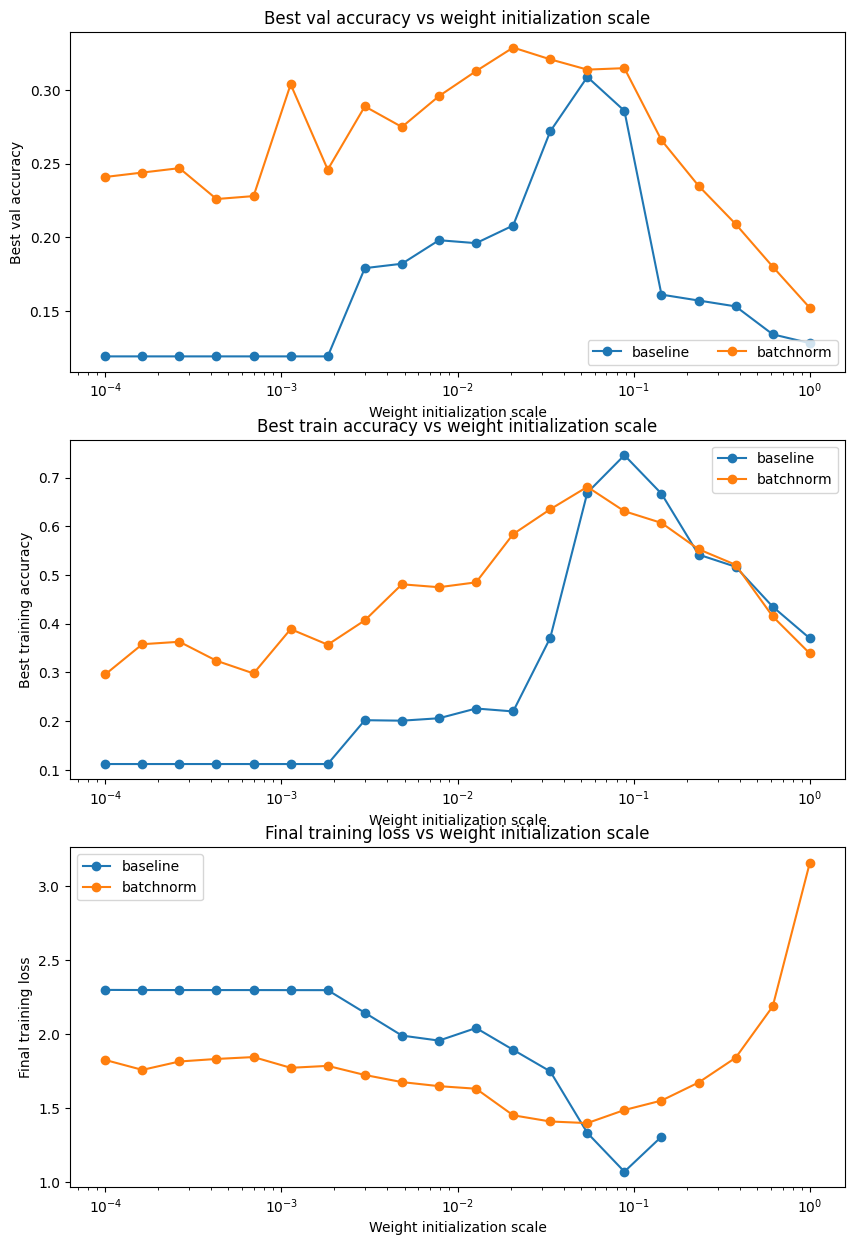

In [ ]:
# Plot results of weight scale experiment
best_train_accs, bn_best_train_accs = [], []
best_val_accs, bn_best_val_accs = [], []
final_train_loss, bn_final_train_loss = [], []

for i, ws in enumerate(weight_scales):
    best_train_accs.append(max(solvers[ws].train_acc_history))
    bn_best_train_accs.append(max(bn_solvers[ws].train_acc_history))

    best_val_accs.append(max(solvers[ws].val_acc_history))
    bn_best_val_accs.append(max(bn_solvers[ws].val_acc_history))

    final_train_loss.append(np.mean(solvers[ws].loss_history[-100:]))
    bn_final_train_loss.append(np.mean(bn_solvers[ws].loss_history[-100:]))


    solvers[ws].record_histories_as_npz('submission_logs/bn_and_weight_scale_experiments_scale{}_no_bn.npz'.format(i))
    bn_solvers[ws].record_histories_as_npz('submission_logs/bn_and_weight_scale_experiments_scale{}_with_bn.npz'.format(i))

plt.subplot(3, 1, 1)
plt.title('Best val accuracy vs weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Best val accuracy')
plt.semilogx(weight_scales, best_val_accs, '-o', label='baseline')
plt.semilogx(weight_scales, bn_best_val_accs, '-o', label='batchnorm')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
plt.title('Best train accuracy vs weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Best training accuracy')
plt.semilogx(weight_scales, best_train_accs, '-o', label='baseline')
plt.semilogx(weight_scales, bn_best_train_accs, '-o', label='batchnorm')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('Final training loss vs weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Final training loss')
plt.semilogx(weight_scales, final_train_loss, '-o', label='baseline')
plt.semilogx(weight_scales, bn_final_train_loss, '-o', label='batchnorm')
plt.legend()

plt.gcf().set_size_inches(10, 15)
plt.show()

In [ ]:
x = np.random.randn(500, 500) + 10

for p in [0.3, 0.6, 0.75]:
    out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
    out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})

    print ('Running tests with p = ', p)
    print ('Mean of input: ', x.mean())
    # expected: (approx.) 10, 10, 10
    print ('Mean of train-time output: ', out.mean())
    # expected: (approx.) 10, 10, 10
    print ('Mean of test-time output: ', out_test.mean())
    # expected: (approx.) 10, 10, 10
    print ('Fraction of train-time output set to zero: ', (out == 0).mean())
    # expected: (approx.) 0.3, 0.6, 0.75
    print ('Fraction of test-time output set to zero: ', (out_test == 0).mean())
    # expected: (approx.) 0.0, 0.0, 0.0

Running tests with p =  0.3
Mean of input:  10.000349084992713
Mean of train-time output:  10.007361545208365
Mean of test-time output:  10.000349084992713
Fraction of train-time output set to zero:  0.29956
Fraction of test-time output set to zero:  0.0
Running tests with p =  0.6
Mean of input:  10.000349084992713
Mean of train-time output:  9.983321898892372
Mean of test-time output:  10.000349084992713
Fraction of train-time output set to zero:  0.60068
Fraction of test-time output set to zero:  0.0
Running tests with p =  0.75
Mean of input:  10.000349084992713
Mean of train-time output:  10.015603879617343
Mean of test-time output:  10.000349084992713
Fraction of train-time output set to zero:  0.749624
Fraction of test-time output set to zero:  0.0


In [ ]:
# Train two identical nets, one with dropout and one without

num_train = 500
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}
dropout_choices = [0, 0.5]
for dropout in dropout_choices:
    model = FullyConnectedNet([500], dropout=dropout)
    print (dropout)

    np.random.seed(seed)
    solver = Solver(model, small_data,
                  num_epochs=15, batch_size=100,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 5e-4,
                  },
                  verbose=True, print_every=100)
    solver.train()
    solvers[dropout] = solver


0
(Iteration 1 / 75) loss: 6.812677
(Epoch 0 / 15) train acc: 0.246000; val_acc: 0.182000


/tmp/ipython-input-9-4011303982.py:401: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(probs[np.arange(N), y])) / N


(Epoch 1 / 15) train acc: 0.332000; val_acc: 0.222000
(Epoch 2 / 15) train acc: 0.460000; val_acc: 0.232000
(Epoch 3 / 15) train acc: 0.548000; val_acc: 0.253000
(Epoch 4 / 15) train acc: 0.694000; val_acc: 0.264000
(Epoch 5 / 15) train acc: 0.730000; val_acc: 0.269000
(Epoch 6 / 15) train acc: 0.764000; val_acc: 0.261000
(Epoch 7 / 15) train acc: 0.846000; val_acc: 0.275000
(Epoch 8 / 15) train acc: 0.868000; val_acc: 0.271000
(Epoch 9 / 15) train acc: 0.920000; val_acc: 0.287000
(Epoch 10 / 15) train acc: 0.942000; val_acc: 0.278000
(Epoch 11 / 15) train acc: 0.946000; val_acc: 0.276000
(Epoch 12 / 15) train acc: 0.966000; val_acc: 0.294000
(Epoch 13 / 15) train acc: 0.962000; val_acc: 0.294000
(Epoch 14 / 15) train acc: 0.970000; val_acc: 0.294000
(Epoch 15 / 15) train acc: 0.980000; val_acc: 0.296000
0.5
(Iteration 1 / 75) loss: 11.328885
(Epoch 0 / 15) train acc: 0.216000; val_acc: 0.161000
(Epoch 1 / 15) train acc: 0.392000; val_acc: 0.244000
(Epoch 2 / 15) train acc: 0.476000; v

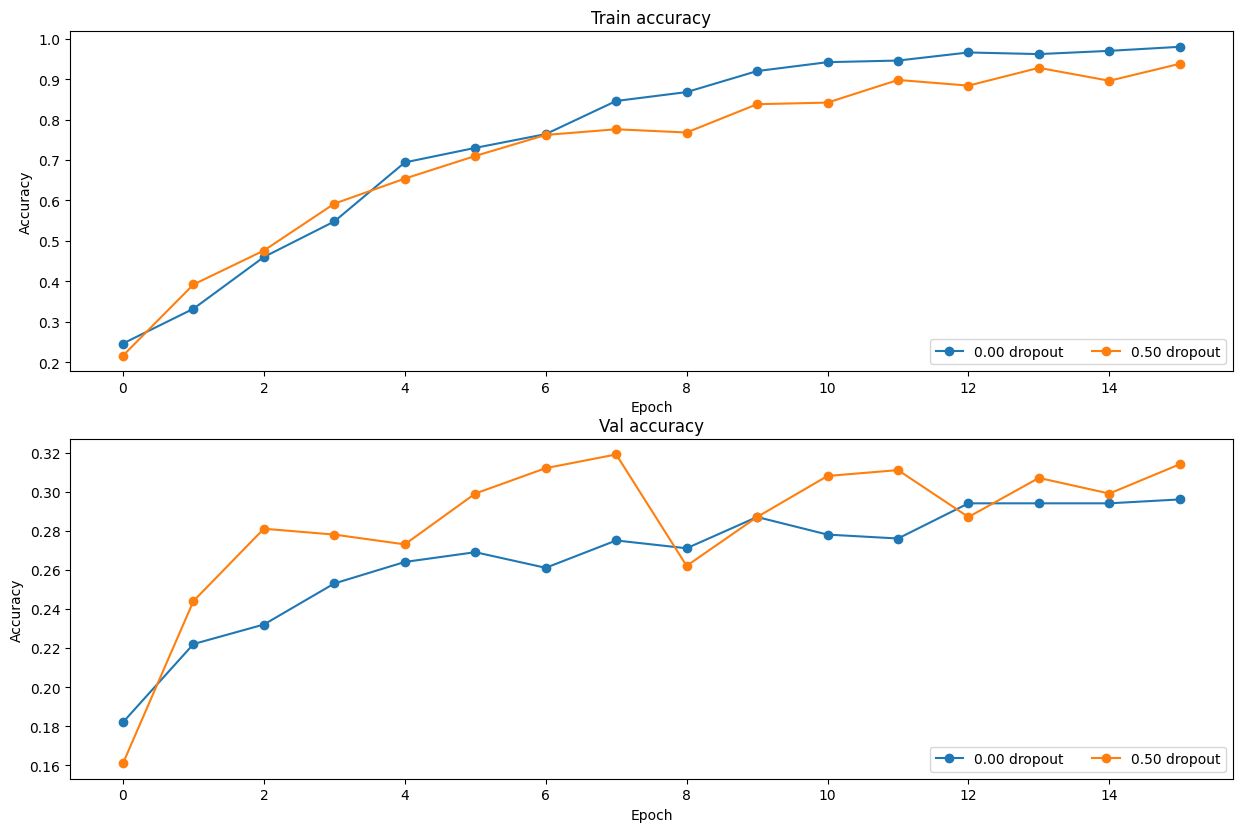

In [ ]:
# Plot train and validation accuracies of the two models

train_accs = []
val_accs = []
for dropout in dropout_choices:
    solver = solvers[dropout]
    train_accs.append(solver.train_acc_history[-1])
    val_accs.append(solver.val_acc_history[-1])
    solver.record_histories_as_npz('submission_logs/dropout_regularization_experiment_p{}.npz'.format(dropout))

plt.subplot(3, 1, 1)
for dropout in dropout_choices:
    plt.plot(solvers[dropout].train_acc_history, '-o', label='%.2f dropout' % dropout)
plt.title('Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
for dropout in dropout_choices:
    plt.plot(solvers[dropout].val_acc_history, '-o', label='%.2f dropout' % dropout)
plt.title('Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')

plt.gcf().set_size_inches(15, 15)
plt.show()

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils as utils
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

os.makedirs("submission_logs", exist_ok=True)
torch.cuda.is_available()
# make sure GPU is enabled
seed = 227

In [ ]:
valid_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),   # convert image to PyTorch Tensor
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        # normalize to [-1.0, 1.0] (originally [0.0, 1.0])
    ]
)

train_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.RandomHorizontalFlip()   # data augmentation
    ]
)

# Download training data from open datasets.
training_data = datasets.CIFAR100(
    root="data",
    train=True,
    download=True,
    transform=train_transform,
)

# Download test data from open datasets.
valid_test_data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=valid_test_transform,
)

# split original test data to valid data and test data
valid_data = list(valid_test_data)[::2]
test_data = list(valid_test_data)[1::2]

classes = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "cra",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple_tree",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak_tree",
    "orange",
    "orchid",
    "otter",
    "palm_tree",
    "pear",
    "pickup_truck",
    "pine_tree",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow_tree",
    "wolf",
    "woman",
    "worm",
]

In [ ]:
# Create data loaders.
valid_dataloader = utils.data.DataLoader(valid_data, batch_size=5)

for X, y in valid_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([5, 3, 32, 32])
Shape of y: torch.Size([5]) torch.int64


In [ ]:
seed = 227


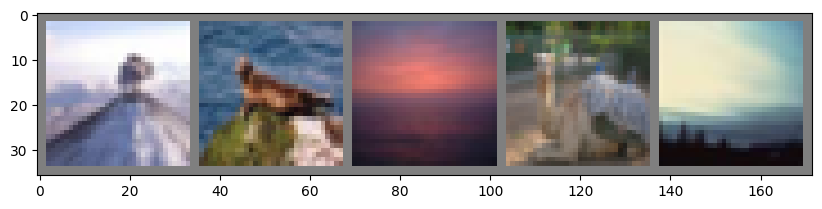

mountain   seal    sea     camel   cloud


In [ ]:
# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(valid_dataloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print('   '.join(f'{classes[labels[j]]:5s}' for j in range(5)))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class NeuralNetwork(nn.Module):
    def __init__(self, do_batchnorm=True, p_dropout=0.3):
        super().__init__()
        self.do_batchnorm = do_batchnorm
        self.p_dropout = p_dropout

        def conv_block(in_channels, out_channels):
            layers = [
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            ]
            if do_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            return nn.Sequential(*layers)

        self.conv1 = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2)  # 32x32 to 16x16
        )

        self.conv2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2)  # 16x16 to 8x8
        )

        self.conv3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2)  # 8x8 to 4x4
        )

        self.conv4 = nn.Sequential(
            conv_block(128, 256),  # 4x4
        )

        self.flat_dim = 256 * 4 * 4  # = 4096

        self.fc1 = nn.Linear(self.flat_dim, 512)
        self.drop1 = nn.Dropout(p_dropout)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        if self.p_dropout > 0.0:
            x = self.drop1(x)
        x = self.fc2(x)
        return x


In [ ]:
model = NeuralNetwork()
print("Parameter keys:")
for k in model.state_dict().keys():
    print("-", k)

print("Total param tensors:", len(model.state_dict()))


Parameter keys:
- conv1.0.0.weight
- conv1.0.0.bias
- conv1.0.1.weight
- conv1.0.1.bias
- conv1.0.1.running_mean
- conv1.0.1.running_var
- conv1.0.1.num_batches_tracked
- conv1.1.0.weight
- conv1.1.0.bias
- conv1.1.1.weight
- conv1.1.1.bias
- conv1.1.1.running_mean
- conv1.1.1.running_var
- conv1.1.1.num_batches_tracked
- conv2.0.0.weight
- conv2.0.0.bias
- conv2.0.1.weight
- conv2.0.1.bias
- conv2.0.1.running_mean
- conv2.0.1.running_var
- conv2.0.1.num_batches_tracked
- conv2.1.0.weight
- conv2.1.0.bias
- conv2.1.1.weight
- conv2.1.1.bias
- conv2.1.1.running_mean
- conv2.1.1.running_var
- conv2.1.1.num_batches_tracked
- conv3.0.0.weight
- conv3.0.0.bias
- conv3.0.1.weight
- conv3.0.1.bias
- conv3.0.1.running_mean
- conv3.0.1.running_var
- conv3.0.1.num_batches_tracked
- conv3.1.0.weight
- conv3.1.0.bias
- conv3.1.1.weight
- conv3.1.1.bias
- conv3.1.1.running_mean
- conv3.1.1.running_var
- conv3.1.1.num_batches_tracked
- conv4.0.0.weight
- conv4.0.0.bias
- conv4.0.1.weight
- conv4.0.1

In [ ]:
#from dl_pytorch.model import NeuralNetwork

model = NeuralNetwork()
print(model)
'''
assert len(model.state_dict()) == 10
assert model.conv1.weight.shape == torch.Size([16, 3, 3, 3])
assert model.conv1.bias.shape == torch.Size([16])
assert model.conv2.weight.shape == torch.Size([32, 16, 3, 3])
assert model.conv2.bias.shape == torch.Size([32])
assert model.conv3.weight.shape == torch.Size([64, 32, 3, 3])
assert model.conv3.bias.shape == torch.Size([64])
assert model.fc1.weight.shape == torch.Size([256, 1024])
assert model.fc1.bias.shape == torch.Size([256])
assert model.fc2.weight.shape == torch.Size([100, 256])
assert model.fc2.bias.shape == torch.Size([100])
assert model(torch.randn(9, 3, 32, 32)).shape == torch.Size([9, 100])
'''
model = NeuralNetwork(do_batchnorm=True, p_dropout=0.1)
'''
assert len(model.state_dict()) == 25
assert model.bn1.weight.shape == model.bn1.bias.shape == torch.Size([16])
assert model.bn2.weight.shape == model.bn2.bias.shape == torch.Size([32])
assert model.bn3.weight.shape == model.bn3.bias.shape == torch.Size([64])
assert model(torch.randn(11, 3, 32, 32)).shape == torch.Size([11, 100])
'''

NeuralNetwork(
  (conv1): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )


'\nassert len(model.state_dict()) == 25\nassert model.bn1.weight.shape == model.bn1.bias.shape == torch.Size([16])\nassert model.bn2.weight.shape == model.bn2.bias.shape == torch.Size([32])\nassert model.bn3.weight.shape == model.bn3.bias.shape == torch.Size([64])\nassert model(torch.randn(11, 3, 32, 32)).shape == torch.Size([11, 100])\n'

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.cuda(), y.cuda()

        # Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss_val = loss.item()
            current = batch * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")


In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.cuda(), y.cuda()
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Evaluation Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 100*correct

In [ ]:
def get_optimizer(params, optim_type, lr, momentum, lr_decay, l2_reg):
    if optim_type == "sgd":
        optimizer = optim.SGD(params, lr=lr, momentum=0.0, weight_decay=l2_reg)
    elif optim_type == "sgd_momentum":
        optimizer = optim.SGD(params, lr=lr, momentum=momentum,
                              weight_decay=l2_reg)
    elif optim_type == "adam":
        optimizer = optim.AdamW(params, lr=lr, betas=(momentum, 0.999),
                                weight_decay=l2_reg)
    else:
        raise ValueError(optim_type)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, lr_decay)
    return optimizer, scheduler

In [ ]:
def run_training(hp, nn_cls, save_prefix):
    print("Hyperparameters:", hp)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

    model = nn_cls(do_batchnorm=hp.do_batchnorm, p_dropout=hp.p_dropout).cuda()

    # Create data loaders.
    train_dataloader = utils.data.DataLoader(
        training_data, batch_size=hp.batch_size)
    valid_dataloader = utils.data.DataLoader(
        valid_data, batch_size=hp.batch_size)

    loss_fn = nn.CrossEntropyLoss()
    optimizer, scheduler = get_optimizer(
        model.parameters(), hp.optim_type, hp.lr, hp.momentum, hp.lr_decay,
        hp.l2_reg)

    for t in range(hp.epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)
        test(valid_dataloader, model, loss_fn)
        scheduler.step()


    print(f"Saving the model to submission_logs/{save_prefix}.pt")
    torch.save(model.state_dict(), f"submission_logs/{save_prefix}.pt")
    return model

def eval_on_test(hp, model, save_prefix):
    train_dataloader = utils.data.DataLoader(
        training_data, batch_size=hp.batch_size)
    test_dataloader = utils.data.DataLoader(
        test_data, batch_size=hp.batch_size)
    loss_fn = nn.CrossEntropyLoss()
    print("Evaluating on the test set")
    test_acc = test(test_dataloader, model, loss_fn)
    n_params = sum(p.numel() for p in model.parameters())
    print("Parameter count: {}".format(n_params))
    n_steps = len(train_dataloader) * hp.epochs
    print("Training steps: {}".format(n_steps))
    with open(f"submission_logs/{save_prefix}.json", "w", encoding="utf-8") as f:
        json.dump({
            "test_acc": test_acc,
            "hparams": hp.__dict__,
            "n_params": n_params,
            "n_steps": n_steps
        }, f)

In [ ]:
from types import SimpleNamespace as Namespace

hp_my_model = Namespace(
    batch_size=64,
    lr=1e-3,
    momentum=0.9,
    lr_decay=0.95,
    optim_type='adam',
    l2_reg=5e-4,
    epochs=10,
    do_batchnorm=True,
    p_dropout=0.3
)

model = run_training(hp_my_model, NeuralNetwork, "model")
eval_on_test(hp_my_model, model, "model")

Hyperparameters: namespace(batch_size=64, lr=0.001, momentum=0.9, lr_decay=0.95, optim_type='adam', l2_reg=0.0005, epochs=10, do_batchnorm=True, p_dropout=0.3)
Epoch 1
-------------------------------
loss: 4.577891  [    0/50000]
loss: 4.078558  [ 6400/50000]
loss: 4.100474  [12800/50000]
loss: 3.639740  [19200/50000]
loss: 3.439807  [25600/50000]
loss: 3.734149  [32000/50000]
loss: 3.571774  [38400/50000]
loss: 3.423954  [44800/50000]
Evaluation Error: 
 Accuracy: 20.9%, Avg loss: 3.194696 

Epoch 2
-------------------------------
loss: 3.437044  [    0/50000]
loss: 3.261994  [ 6400/50000]
loss: 2.938933  [12800/50000]
loss: 2.811538  [19200/50000]
loss: 2.868030  [25600/50000]
loss: 3.128061  [32000/50000]
loss: 3.033501  [38400/50000]
loss: 2.709776  [44800/50000]
Evaluation Error: 
 Accuracy: 29.1%, Avg loss: 2.710594 

Epoch 3
-------------------------------
loss: 2.931177  [    0/50000]
loss: 2.783406  [ 6400/50000]
loss: 2.401579  [12800/50000]
loss: 2.326113  [19200/50000]
loss